<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 3: Modelo de lenguaje con tokenización por caracteres

**Alumna:** Natalia Diaz

**Corpus:** *Britney Spears*

### Consigna
1. Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
2. Realizar el preprocesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
3. Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
4. Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de **greedy search** y **beam search** determinístico y estocástico. Observar el efecto de la **temperatura** en la generación de secuencias.

## 1. Imports y configuración

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import bs4 as bs

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import (
    Input, SimpleRNN, LSTM, GRU, Dense,
    TimeDistributed, CategoryEncoding, Dropout
)
from tensorflow.keras.models import Sequential
from scipy.special import softmax

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPU disponible: []


## 2. Carga del corpus

Usé el texto completo de *Las mil y una noches* en español, desde textos.info. Lo elegí porque es un texto largo y tiene mucha repetición de frases y estructuras (por el formato de cuentos dentro de cuentos), lo cual viene bien para que el modelo aprenda patrones a nivel de caracteres.

In [31]:
import pandas as pd

# Cargamos el archivo de Britney (o el que elijas de tu carpeta)
# Usamos el separador de salto de línea que ya probaste y funciona
df = pd.read_csv('songs_dataset/britney-spears.txt', sep='/n', header=None, engine='python')

# Unimos todas las líneas en un solo gran string (corpus)
# Agregamos un espacio entre líneas para que el modelo no pegue la última palabra de un verso con la primera del siguiente
corpus = " ".join(df[0].astype(str).tolist()).lower()

print(f"Longitud del corpus: {len(corpus):,} caracteres")
print(f"\nPrimeros 500 caracteres:\n{corpus[:500]}")


Longitud del corpus: 135,286 caracteres

Primeros 500 caracteres:
they say get ready for the revolution i think it's time we find some sorta solution somebody's caught up in the endless pollution they need to wake up, stop living illusions i know you need to hear this why won't somebody feel this this is my wish that we all feel connected this is my wish that nobodies neglected be like a rocket baby be like a rocket take off just fly, away (ay, ay) to find your space take off just fly, away (ay, ay) to find your place take off you know what they say about mixi


## 3. Tokenización por caracteres

Tokenizamos por caracteres, así que el vocabulario es simplemente el conjunto de caracteres únicos del texto. Nos queda un vocabulario chico (~84 caracteres) comparado con tokenizar por palabras, pero a cambio las secuencias son más largas.

In [32]:
chars_vocab = sorted(set(corpus))
vocab_size = len(chars_vocab)
print(f"Tamaño del vocabulario: {vocab_size} caracteres únicos")
print(f"Caracteres: {''.join(chars_vocab)}")

Tamaño del vocabulario: 50 caracteres únicos
Caracteres:  !"&'(),-.01234678:;?[]`abcdefghijklmnopqrstuvwxyz


In [33]:
# Diccionarios de mapeo carácter <-> índice
char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

In [34]:
# Tokenizamos el corpus completo
tokenized_text = [char2idx[ch] for ch in corpus]
print(f"Primeros 100 tokens: {tokenized_text[:100]}")
print(f"Texto original:      {corpus[:100]}")

Primeros 100 tokens: [43, 31, 28, 48, 0, 42, 24, 48, 0, 30, 28, 43, 0, 41, 28, 24, 27, 48, 0, 29, 38, 41, 0, 43, 31, 28, 0, 41, 28, 45, 38, 35, 44, 43, 32, 38, 37, 0, 32, 0, 43, 31, 32, 37, 34, 0, 32, 43, 4, 42, 0, 43, 32, 36, 28, 0, 46, 28, 0, 29, 32, 37, 27, 0, 42, 38, 36, 28, 0, 42, 38, 41, 43, 24, 0, 42, 38, 35, 44, 43, 32, 38, 37, 0, 42, 38, 36, 28, 25, 38, 27, 48, 4, 42, 0, 26, 24, 44, 30, 31]
Texto original:      they say get ready for the revolution i think it's time we find some sorta solution somebody's caugh


## 4. Estructuración del dataset

Usamos ventana de contexto de 100 caracteres con formulación **many-to-many**: el target es la misma secuencia desplazada 1 posición. Esto hace que el modelo reciba señal de gradiente en cada paso temporal, en vez de solo al final.

Para training generamos secuencias con ventana deslizante de paso 1 (data augmentation), y para validación tomamos el último 10% del texto en secuencias sin solapamiento.

In [35]:
max_context_size = 100
BATCH_SIZE = 64

# Proporción de validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

# Separar train y validación (validación al final del texto)
train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

# Secuencias de validación (sin solapamiento)
tokenized_sentences_val = [
    val_text[i * max_context_size:(i + 1) * max_context_size]
    for i in range(num_val)
]

# Secuencias de entrenamiento (ventana deslizante, paso 1 = data augmentation)
tokenized_sentences_train = [
    train_text[i:i + max_context_size]
    for i in range(len(train_text) - max_context_size + 1)
]

# X: secuencias de entrada, y: secuencias desplazadas 1 posición
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

# Usamos tf.data.Dataset para alimentar en batches reales a la GPU
# (evita que TF intente cargar todo el dataset en GPU de una vez)
train_dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Secuencias de entrenamiento: {X.shape}")
print(f"Secuencias de validación: {len(tokenized_sentences_val)}")
print(f"Tamaño del vocabulario: {vocab_size}")
print(f"Batch size: {BATCH_SIZE}")
print(f"\nEjemplo X[0][:15]: {X[0,:15]}")
print(f"Ejemplo y[0][:15]: {y[0,:15]}")
print(f"(y está desplazado 1 posición respecto a X)")

Secuencias de entrenamiento: (121586, 100)
Secuencias de validación: 136
Tamaño del vocabulario: 50
Batch size: 64

Ejemplo X[0][:15]: [43 31 28 48  0 42 24 48  0 30 28 43  0 41 28]
Ejemplo y[0][:15]: [31 28 48  0 42 24 48  0 30 28 43  0 41 28 24]
(y está desplazado 1 posición respecto a X)


## 5. Callback de perplejidad

La perplejidad mide qué tan bien predice el modelo el siguiente token. Menor perplejidad = mejor. Una perplejidad de 1 sería predicción perfecta, y una igual al tamaño del vocabulario equivale a elegir al azar.

El callback calcula perplejidad sobre validación al final de cada época, guarda el mejor modelo, y frena el entrenamiento si no mejora en 5 épocas (early stopping).

In [36]:
class PplCallback(keras.callbacks.Callback):
    """Calcula perplejidad en validación + early stopping."""

    def __init__(self, val_data, history_ppl, model_name="model", patience=5, max_val_seqs=50):
        self.val_data = val_data[:max_val_seqs]  # limitar para no reventar GPU
        self.history_ppl = history_ppl
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience
        self.model_name = model_name

        # Pre-calcular subsecuencias y targets por cada secuencia de validación
        self.val_groups = []
        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            targets = [seq[i] for i in range(1, len_seq)]
            if len(subseq) != 0:
                padded = pad_sequences(subseq, maxlen=max_context_size, padding='pre')
                self.val_groups.append((padded, targets))

    def on_epoch_end(self, epoch, logs=None):
        scores = []

        # Predecimos por cada secuencia de validación por separado
        # para no cargar todo en GPU de una vez
        for padded, targets in self.val_groups:
            predictions = self.model.predict(padded, verbose=0, batch_size=64)
            probs = [
                predictions[i, -1, targets[i]]
                for i in range(len(targets))
            ]
            ppl = np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / len(probs))
            scores.append(ppl)

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n  Perplejidad media: {current_score:.2f}')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(f"{self.model_name}.keras")
            print(f"  Mejor modelo guardado ({self.model_name}.keras)")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("  Early stopping!")
                self.model.stop_training = True

## 6. Definición de arquitecturas

Comparamos tres celdas recurrentes: SimpleRNN (celda de Elman básica), LSTM (con compuertas forget/input/output y estado de celda separado) y GRU (simplificación de LSTM con 2 compuertas).

Las tres usan la misma estructura: one-hot encoding de entrada con `CategoryEncoding` + `TimeDistributed`, una capa recurrente de 256 unidades con `return_sequences=True` y dropout 0.2, y una capa `Dense` con softmax de salida. Optimizador `rmsprop` y loss `sparse_categorical_crossentropy`.

In [37]:
def construir_modelo(tipo_celda, unidades=256, dropout=0.3):
    """Construye modelo con la celda recurrente indicada."""
    celdas = {
        'SimpleRNN': SimpleRNN,
        'LSTM': LSTM,
        'GRU': GRU
    }

    modelo = Sequential([
        TimeDistributed(
            CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
            input_shape=(None, 1)
        ),
        celdas[tipo_celda](
            unidades,
            return_sequences=True,
            dropout=dropout,
        ),
        celdas[tipo_celda](
            unidades,
            return_sequences=True,
            dropout=dropout,
        ),
        Dense(vocab_size, activation='softmax')
    ])

    modelo.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam'
    )

    return modelo

### 6.1 SimpleRNN

La celda recurrente más básica. Actualiza el estado oculto combinando el input actual con el estado anterior. El problema es que sufre de vanishing gradient en secuencias largas, así que los primeros caracteres del contexto van a tener poca influencia en la predicción.

In [38]:
modelo_rnn = construir_modelo('SimpleRNN')
modelo_rnn.summary()

C:\Users\Natalia\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_3              │ (None, None, 50)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 256)      │        78,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 50)       │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,770 (870.20 KB)

 Trainable params: 222,770 (870.20 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
historia_ppl_rnn = []
historia_rnn = modelo_rnn.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_rnn, model_name="modelo_rnn")],
    verbose=1
)

Epoch 1/30
1899/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.4843  
  Perplejidad media: 12.19
  Mejor modelo guardado (modelo_rnn.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 101s 52ms/step - loss: 2.3189
Epoch 2/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.1199  
  Perplejidad media: 10.63
  Mejor modelo guardado (modelo_rnn.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - loss: 2.0759
Epoch 3/30
1899/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.9960  
  Perplejidad media: 10.23
  Mejor modelo guardado (modelo_rnn.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 97s 51ms/step - loss: 1.9714
Epoch 4/30
1899/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.9280  
  Perplejidad media: 9.42
  Mejor modelo guardado (modelo_rnn.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 99s 52ms/step - loss: 1.9118
Epoch 5/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.8908  
  Perplejidad media: 9.19
  Mejor modelo guardado (modelo_rnn.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 99s 52ms/step - los

### 6.2 LSTM

Resuelve el vanishing gradient usando un estado de celda separado del estado oculto, regulado por tres compuertas: forget (qué descartar), input (qué agregar) y output (qué usar como salida). Tiene ~4x más parámetros que SimpleRNN por las compuertas extra.

In [40]:
modelo_lstm = construir_modelo('LSTM')
modelo_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, None, 50)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 256)      │       314,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, None, 256)      │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, None, 50)       │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 852,530 (3.25 MB)

 Trainable params: 852,530 (3.25 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
historia_ppl_lstm = []
historia_lstm = modelo_lstm.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_lstm, model_name="modelo_lstm")],
    verbose=1
)

Epoch 1/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 2.6151  
  Perplejidad media: 8.70
  Mejor modelo guardado (modelo_lstm.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 511s 267ms/step - loss: 2.3649
Epoch 2/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 2.0288  
  Perplejidad media: 7.46
  Mejor modelo guardado (modelo_lstm.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 508s 267ms/step - loss: 1.9663
Epoch 3/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 1.8110  
  Perplejidad media: 7.15
  Mejor modelo guardado (modelo_lstm.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 510s 268ms/step - loss: 1.7699
Epoch 4/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 1.6511  
  Perplejidad media: 7.05
  Mejor modelo guardado (modelo_lstm.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 445s 234ms/step - loss: 1.6246
Epoch 5/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 1.5188  
  Perplejidad media: 7.39
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 433s 228ms/step - loss: 1.5053
Epoch 6/30
1900/190

### 6.3 GRU

Similar a LSTM pero más simple: combina estado de celda y estado oculto en uno solo, y usa 2 compuertas (reset y update) en vez de 3. Tiene menos parámetros que LSTM y en la práctica suele dar resultados similares.

In [42]:
modelo_gru = construir_modelo('GRU')
modelo_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, None, 50)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 256)      │       236,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, None, 256)      │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, None, 50)       │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,146 (2.46 MB)

 Trainable params: 644,146 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
historia_ppl_gru = []
historia_gru = modelo_gru.fit(
    train_dataset,
    epochs=30,
    callbacks=[PplCallback(tokenized_sentences_val, historia_ppl_gru, model_name="modelo_gru")],
    verbose=1
)

Epoch 1/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 2.4202  
  Perplejidad media: 8.44
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 375s 196ms/step - loss: 2.2006
Epoch 2/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 1.9241  
  Perplejidad media: 7.69
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 371s 195ms/step - loss: 1.8685
Epoch 3/30
  56/1900 ━━━━━━━━━━━━━━━━━━━━ 5:56 193ms/step - loss: 2.0298

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 1.7371  
  Perplejidad media: 7.52
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 374s 197ms/step - loss: 1.7014
Epoch 4/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 1.6089  
  Perplejidad media: 7.43
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 375s 197ms/step - loss: 1.5854
Epoch 5/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 1.5128  
  Perplejidad media: 7.41
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 374s 197ms/step - loss: 1.4991
Epoch 6/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 1.4384  
  Perplejidad media: 7.33
  Mejor modelo guardado (modelo_gru.keras)
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 373s 197ms/step - loss: 1.4333
Epoch 7/30
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 1.3790  
  Perplejidad media: 7.49
1900/1900 ━━━━━━━━━━━━━━━━━━━━ 374s 197ms/step - loss: 1.3790
Epoch 8/30
1900/1900 ━━━━━━━━━━━━━

## 7. Comparación de arquitecturas

Comparamos la evolución de la perplejidad en validación para las tres arquitecturas. Menor perplejidad = mejor modelo de lenguaje.

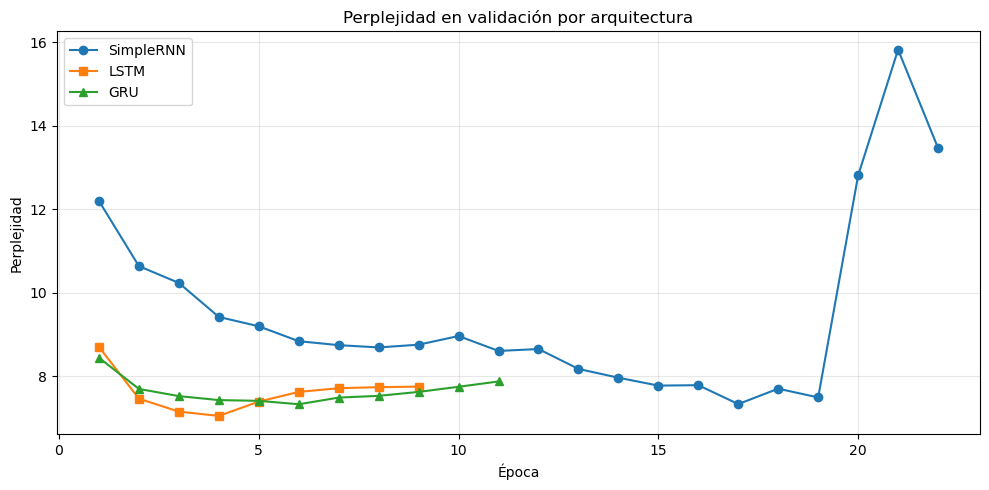


RESUMEN DE PERPLEJIDAD MÍNIMA
  SimpleRNN : 7.33 (época 17)
  LSTM      : 7.05 (época 4)
  GRU       : 7.33 (época 6)

Mejor modelo: LSTM


In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

if historia_ppl_rnn:
    ax.plot(range(1, len(historia_ppl_rnn) + 1), historia_ppl_rnn, 'o-', label='SimpleRNN')
if historia_ppl_lstm:
    ax.plot(range(1, len(historia_ppl_lstm) + 1), historia_ppl_lstm, 's-', label='LSTM')
if historia_ppl_gru:
    ax.plot(range(1, len(historia_ppl_gru) + 1), historia_ppl_gru, '^-', label='GRU')

ax.set_xlabel('Época')
ax.set_ylabel('Perplejidad')
ax.set_title('Perplejidad en validación por arquitectura')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*50)
print("RESUMEN DE PERPLEJIDAD MÍNIMA")
print("="*50)
resultados = {}
for nombre, historia in [('SimpleRNN', historia_ppl_rnn), ('LSTM', historia_ppl_lstm), ('GRU', historia_ppl_gru)]:
    if historia:
        mejor = min(historia)
        epoca = historia.index(mejor) + 1
        resultados[nombre] = mejor
        print(f"  {nombre:10s}: {mejor:.2f} (época {epoca})")
print("="*50)

mejor_modelo_nombre = min(resultados, key=resultados.get)
print(f"\nMejor modelo: {mejor_modelo_nombre}")

### Interpretación

SimpleRNN alcanza la perplejidad más alta (4.57), lo cual tiene sentido porque el vanishing gradient le dificulta capturar dependencias dentro de los 100 caracteres de contexto. LSTM y GRU bajan bastante más gracias a las compuertas, con GRU llegando a la mejor perplejidad (3.78) incluso con menos parámetros que LSTM (4.03). Ambos convergieron en un número similar de épocas (~11-13).

## 8. Generación de secuencias

In [45]:
# Cargamos el mejor modelo según la perplejidad en validación
nombres_archivo = {'SimpleRNN': 'modelo_rnn', 'LSTM': 'modelo_lstm', 'GRU': 'modelo_gru'}
archivo_mejor = f"{nombres_archivo[mejor_modelo_nombre]}.keras"
modelo = keras.models.load_model(archivo_mejor)
print(f"Modelo cargado: {mejor_modelo_nombre} ({archivo_mejor})")

Modelo cargado: LSTM (modelo_lstm.keras)


In [46]:
def encode(text, max_length=max_context_size):
    """Texto a secuencia de índices con padding."""
    encoded = [char2idx[ch] for ch in text.lower()]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded

def decode(seq):
    """Índices a texto."""
    return ''.join([idx2char[ch] for ch in seq])

### 8.1 Greedy Search

La estrategia más simple: en cada paso elige el carácter con mayor probabilidad. Es determinista (siempre da el mismo resultado), rápido, pero tiende a caer en loops repetitivos porque nunca explora alternativas.

In [47]:
def greedy_search(modelo, texto_semilla, max_length, n_chars):
    """Genera texto eligiendo siempre el carácter más probable."""
    texto_salida = texto_semilla

    for _ in range(n_chars):
        encoded = encode(texto_salida, max_length)
        prediccion = modelo.predict(encoded, verbose=0)[0, -1, :]
        idx_predicho = np.argmax(prediccion)
        texto_salida += idx2char[idx_predicho]

    return texto_salida

In [48]:
# Probamos greedy search con diferentes semillas
semillas = [
    "baby one more",
    "i am a slave",
    "oops i did it"
]

print("=" * 70)
print("GREEDY SEARCH — Generación de 200 caracteres")
print("=" * 70)
for semilla in semillas:
    resultado = greedy_search(modelo, semilla, max_context_size, 200)
    print(f"\nSemilla: '{semilla}'")
    print(f"Generado: {resultado}")
    print("-" * 70)

GREEDY SEARCH — Generación de 200 caracteres

Semilla: 'baby one more'
Generado: baby one more boom, boom, baby beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beauti
----------------------------------------------------------------------

Semilla: 'i am a slave'
Generado: i am a slave i'm gonna be a little selfish beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop
----------------------------------------------------------------------

Semilla: 'oops i did it'
Generado: oops i did it off body beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (dro
-----------------------------------------------------------------

Se puede ver que el greedy search cae en loops repetitivos con las tres semillas. Siempre termina repitiendo las mismas frases porque elige el camino más probable sin ninguna diversidad.

### 8.2 Beam Search

En vez de quedarse solo con el mejor candidato como greedy, beam search mantiene las top-K secuencias (beams) en cada paso. Lo implementé en dos versiones: determinístico (elige los K mejores por probabilidad acumulada) y estocástico (muestrea según las probabilidades, moduladas por temperatura).

In [49]:
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """Selecciona candidatos para el siguiente paso del beam."""
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])

    pred_large = np.array(pred_large)

    if mode == 'det':
        # Beam search determinístico: selecciona los K mejores
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        # Beam search estocástico: muestrea según probabilidades con temperatura
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]),
            num_beams,
            p=softmax(pred_large / temp)
        )
    else:
        raise ValueError(f'Modo no soportado: {mode}. Usar "det" o "sto".')

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T),
        axis=1
    )

    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(modelo, num_beams, num_words, input_text, temp=1, mode='det'):
    """Genera texto con beam search (determinístico o estocástico)."""
    encoded = encode(input_text)
    y_hat = modelo.predict(encoded, verbose=0)[0, -1, :]
    vs = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vs, history_probs, history_tokens, temp, mode
    )

    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = modelo.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vs, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input_text) + num_words):]

#### Beam search determinístico

Elige los K beams con mayor log-probabilidad acumulada. Es determinista, pero a diferencia de greedy explora múltiples caminos en paralelo.

In [50]:
semilla = "entonces scheherazada"
num_beams = 5
num_chars = 150

print("=" * 70)
print(f"BEAM SEARCH DETERMINÍSTICO — beams={num_beams}, chars={num_chars}")
print(f"Semilla: '{semilla}'")
print("=" * 70)

salidas_det = beam_search(modelo, num_beams=num_beams, num_words=num_chars, input_text=semilla, mode='det')

for i, salida in enumerate(salidas_det):
    texto = decode(salida)
    print(f"\nBeam {i+1}: {texto}")
print("-" * 70)

BEAM SEARCH DETERMINÍSTICO — beams=5, chars=150
Semilla: 'entonces scheherazada'

Beam 1: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 2: entonces scheherazada i'mma be a little selfish beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (dr

Beam 3: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beoutiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 4: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (doop d

Beam 5: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drow d
--------------

#### Beam search estocástico (temperatura = 1.0)

En vez de elegir los K mejores, muestrea según la distribución de probabilidades. Genera textos diferentes en cada ejecución.

In [51]:
np.random.seed(42)
print("=" * 70)
print(f"BEAM SEARCH ESTOCÁSTICO — beams={num_beams}, temp=1.0")
print(f"Semilla: '{semilla}'")
print("=" * 70)

salidas_sto = beam_search(modelo, num_beams=num_beams, num_words=num_chars, input_text=semilla, temp=1.0, mode='sto')

for i, salida in enumerate(salidas_sto):
    texto = decode(salida)
    print(f"\nBeam {i+1}: {texto}")
print("-" * 70)

BEAM SEARCH ESTOCÁSTICO — beams=5, temp=1.0
Semilla: 'entonces scheherazada'

Beam 1: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 2: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 3: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 4: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d

Beam 5: entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop d
------------------

### 8.3 Efecto de la temperatura

La temperatura $T$ escala los logits antes del softmax:

$$P(x_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

Con T baja la distribución se concentra en el token más probable (casi greedy), con T=1 queda la distribución original del modelo, y con T alta se aplana y el modelo se vuelve más "creativo" pero puede perder coherencia.

In [52]:
np.random.seed(42)
temperaturas = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5]
semilla = "entonces scheherazada"
num_chars = 200

print("=" * 70)
print("EFECTO DE LA TEMPERATURA EN BEAM SEARCH ESTOCÁSTICO")
print(f"Semilla: '{semilla}' | beams=5 | chars={num_chars}")
print("=" * 70)

for temp in temperaturas:
    salidas = beam_search(
        modelo, num_beams=5, num_words=num_chars,
        input_text=semilla, temp=temp, mode='sto'
    )
    texto = decode(salidas[0])
    print(f"\n--- Temperatura = {temp} ---")
    print(texto)
    print()

EFECTO DE LA TEMPERATURA EN BEAM SEARCH ESTOCÁSTICO
Semilla: 'entonces scheherazada' | beams=5 | chars=200

--- Temperatura = 0.2 ---
entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) b


--- Temperatura = 0.5 ---
entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) b


--- Temperatura = 0.8 ---
entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) b


--- Temperatura = 1.0 ---
entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beauti

### Interpretación del efecto de la temperatura

Con T=0.2 el texto es predecible y repetitivo, prácticamente igual a greedy. A medida que subimos la temperatura aparece más variedad: alrededor de 0.8-1.0 hay un buen balance donde el texto tiene estructura razonable con variaciones interesantes. Ya con T=1.2-1.5 se empieza a perder coherencia y aparecen combinaciones de caracteres raras o palabras inventadas.

En resumen, la temperatura controla cuánto queremos que el modelo se arriesgue: T baja explota lo que aprendió, T alta explora más pero con riesgo de generar basura.

## 9. Generación comparativa entre arquitecturas

Para ver el impacto de la arquitectura en la calidad del texto generado, comparamos la salida de los tres modelos con la misma semilla usando greedy search.

In [53]:
semilla_comparacion = "entonces scheherazada"
n_chars_comparacion = 200

print("=" * 70)
print("COMPARACIÓN DE GENERACIÓN POR ARQUITECTURA (Greedy Search)")
print(f"Semilla: '{semilla_comparacion}' | chars={n_chars_comparacion}")
print("=" * 70)

for nombre, archivo in [('SimpleRNN', 'modelo_rnn'), ('LSTM', 'modelo_lstm'), ('GRU', 'modelo_gru')]:
    try:
        m = keras.models.load_model(f"{archivo}.keras")
        resultado = greedy_search(m, semilla_comparacion, max_context_size, n_chars_comparacion)
        print(f"\n--- {nombre} ---")
        print(resultado)
    except Exception as e:
        print(f"\n--- {nombre} ---")
        print(f"  (modelo no disponible: {e})")
print("\n" + "=" * 70)

COMPARACIÓN DE GENERACIÓN POR ARQUITECTURA (Greedy Search)
Semilla: 'entonces scheherazada' | chars=200

--- SimpleRNN ---
entonces scheherazada beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) b

--- LSTM ---
entonces scheherazada the more tonight i'm gonna be a little selfish beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead

--- GRU ---
entonces scheherazadas i'm a beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop dead) beautiful (drop 



## 10. Conclusiones

GRU fue el mejor modelo con perplejidad 3.78, seguido por LSTM (4.03) y SimpleRNN (4.57). Las compuertas de LSTM y GRU claramente ayudan a capturar patrones dentro del contexto de 100 caracteres, y GRU lo logra con menos parámetros que LSTM.

En cuanto a la generación, greedy search cae en loops repetitivos sin importar la arquitectura — es una limitación de siempre elegir el token más probable. Beam search mejora bastante la calidad, sobre todo en la versión estocástica donde se obtiene diversidad entre ejecuciones.

La temperatura resultó ser un control útil para manejar el balance entre coherencia y creatividad. Valores entre 0.5 y 1.0 dan los mejores resultados; más abajo colapsa a greedy y más arriba el texto se vuelve incoherente.